# MixedGAM 統一示範（Residual vs Affine）
- 單一筆記本涵蓋 MixedGAM 的資料準備、兩種模式的訓練、KPI 檢查與視覺化。
- 補上 MixedGAMConfig 全部參數對照表，以及 tuning / Early Stopping / Checkpoint 的實務指引。
- 方便直接貼給夥伴或客戶，所有說明皆以中文撰寫。


### 正則化設計（Residual / Affine 模式）

總 loss 由三段組成：

$$\mathcal{L}_{total} = \text{MSE}(\hat{y}, y) + \lambda_{base}\,\text{MSE}(f_{base}, y) + \lambda_{center}(\mathbb{E}[r_g])^2 + \lambda_{L1}||W_g||_1 + \lambda_{L2}||W_g||_2 + \lambda_{orth}\cdot\text{Cov}(f_{base}, \Delta_g)^2$$

- $f_{base}$：所有特徵 shape 的總和（shared GAM）。
- $r_g$ / $\Delta_g$：群組殘差或 affine 校正項。
- $\lambda_{base}$ 對應 `lambda_base_target`，強迫共享 trunk 擔任主要趨勢。
- 其它係數分別控制群組平均為零、稀疏/小幅度，以及與共享基底的正交性。


## 1. 環境初始化
- 匯入 PyTorch Lightning callback、sklearn 指標與 MixedGAMRegressor / MixedGAMConfig。
- 固定亂數種子，確保 KPI 與 shape plot 可以被重現。


In [17]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.models import MixedGAMRegressor, MixedGAMConfig

plt.style.use('seaborn-v0_8')
np.random.seed(42)
DATA_URL = '../data/student-por.csv'

## 2. 讀取資料與建立族群欄位
- 使用 UCI student-por 資料，`G3` 為目標欄位，`school` 作為群組 adapter。
- 僅保留連續欄位示範 GAM，並切出 train/test = 75/25，`stratify` 在 school 以維持群組比例。


In [18]:
raw_df = pd.read_csv(DATA_URL)
feature_cols = ['G1', 'G2', 'absences', 'studytime', 'failures', 'Medu', 'Fedu']
target_col = 'G3'
group_col = 'school'

subset = raw_df[feature_cols + [target_col, group_col]].copy()
X = subset[feature_cols]
y = subset[target_col]
groups = subset[group_col]

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.25,
    random_state=42,
    stratify=groups,
)

print(f'Train shape: X={X_train.shape}, Test shape: X={X_test.shape}')
display(X_train.head())
print('族群比例 (train):')
print(g_train.value_counts(normalize=True))


Train shape: X=(486, 7), Test shape: X=(163, 7)


,G1,G2,absences,studytime,failures,Medu,Fedu
125,9,9,2,1,0,3,4
378,17,18,0,1,0,3,3
332,18,18,0,3,0,2,2
415,9,10,5,1,1,4,4
581,6,8,2,2,2,1,2


族群比例 (train):
school
GP    0.652263
MS    0.347737
Name: proportion, dtype: float64


## 3. MixedGAMConfig 參數說明
下表將 `MixedGAMConfig` 的每個欄位分組描述，方便在調參或交接文件時快速對照。

### 3.1 結構與推論
| 分類 | 參數 | 預設值 | 功能解釋 | 示範設定 |
| --- | --- | --- | --- | --- |
| 結構 | `mode` | `group_residual` | 決定群組如何修正全域 GAM；另可設定 `group_affine` | 本筆記同時示範兩種模式 |
| 結構 | `scaler` | `standard` | 決定特徵縮放器，可改為 `robust` 或 `identity` | `standard` |
| Base | `base_hidden_units` | `(64, 32)` | 全域 GAM backbone 的隱藏層維度 | `(64, 32)` |
| Base | `base_activation` | `tanh` | Base GAM 的啟動函數 | `tanh` |
| Base | `base_dropout` | `0.05` | Base GAM 內部 dropout | `0.05` |
| Residual/Affine | `residual_hidden_units` | `(64,)` | 群組 head 的 MLP 尺寸（affine 模式仍沿用） | `(96, 48)` |
| Residual/Affine | `residual_activation` | `relu` | 群組 head 的啟動函數 | `relu` |
| Residual/Affine | `residual_dropout` | `0.1` | 群組 head dropout | `0.1` |
| 裝置 | `device` | `None` | `None` 會自動挑選 GPU/CPU | `cpu` |
| 視覺化 | `num_shape_points` | `200` | shape function 掃描點數 | `200` |

### 3.2 訓練與隨機性
| 分類 | 參數 | 預設值 | 功能解釋 | 示範設定 |
| --- | --- | --- | --- | --- |
| 訓練 | `learning_rate` | `2e-3` | AdamW 的 LR | `1e-3` |
| 訓練 | `weight_decay` | `1e-4` | AdamW 的 L2 | `1e-4` |
| 訓練 | `batch_size` | `128` | DataLoader 的 batch | `128` |
| 訓練 | `n_epochs` | `300` | 最多訓練週期（會被 EarlyStopping 中止） | 140 / 160 |
| 顯示 | `verbose` | `False` | 開啟 Rich bar 與 LR Monitor | `True` |
| 隨機 | `random_state` | `42` | 控制 numpy / torch 隨機性 | `42` |

### 3.3 正則化 / 穩定度
| 分類 | 參數 | 預設值 | 功能解釋 | 示範設定 |
| --- | --- | --- | --- | --- |
| 中心化 | `lambda_center` | `1e-3` | 控制 base shape 的均值對齊 | `1e-3` |
| 群組 | `lambda_group_l1` | `1e-4` | 對群組殘差施加 L1，鼓勵稀疏 | `1e-4` |
| 群組 | `lambda_group_l2` | `1e-4` | 對群組殘差施加 L2，避免爆炸 | `1e-4` |
| 正交 | `lambda_orth` | `1e-4` | 約束 base 與群組 delta 的相關性 | `1e-4` |
| Affine | `lambda_affine_scale` | `1e-4` | 懲罰群組縮放係數偏離 1 | `5e-4` |
| Affine | `lambda_affine_shift` | `1e-4` | 懲罰群組平移量 | `5e-4` |
| Affine | `lambda_affine_center` | `1e-4` | 逼近 affine shift 均值為 0 | `1e-4` |
| Base | `lambda_base_target` | `1e-3` | 將 base sum 拉向真實 y，避免群組過擔責任 | `5e-4` |
| 殘差 | `residual_contribution_l1` | `0.0` | 直接對 `per_feature` 殘差加 L1 | `0.0` |
| 殘差 | `residual_contribution_l2` | `0.0` | 直接對 `per_feature` 殘差加 L2 | `0.0` |

### 3.4 Checkpoint 與監控
| 分類 | 參數 | 預設值 | 功能解釋 | 示範設定 |
| --- | --- | --- | --- | --- |
| Checkpoint | `checkpoint_dir` | `checkpoints` | 檔案輸出資料夾 | `checkpoints/{mode}_demo` |
| Checkpoint | `checkpoint_monitor` | `val_loss` | EarlyStopping / Checkpoint 觀察的 metric | `val_loss` |
| Checkpoint | `checkpoint_mode` | `min` | metric 趨勢方向 | `min` |


In [19]:
default_cfg = pd.Series(asdict(MixedGAMConfig()), name='default')
demo_override = default_cfg.copy()
demo_override.loc['mode'] = 'group_residual'
demo_override.loc['learning_rate'] = 1e-3
demo_override.loc['n_epochs'] = 140
demo_override.loc['lambda_base_target'] = 5e-4
demo_override.loc['lambda_center'] = 1e-3
demo_override.loc['verbose'] = True

cfg_compare = pd.concat(
    [default_cfg.rename('default'), demo_override.rename('demo_common')],
    axis=1,
)

display(cfg_compare)

,default,demo_common
mode,group_residual,group_residual
scaler,standard,standard
base_hidden_units,"(64, 32)","(64, 32)"
base_activation,tanh,tanh
base_dropout,0.05,0.05
residual_hidden_units,"(16,)","(16,)"
residual_activation,relu,relu
residual_dropout,0.1,0.1
learning_rate,0.002,0.001
weight_decay,0.0001,0.0001


### Catboost Baseline

## 4. 訓練與 KPI（Residual vs Affine）
- 針對兩種模式共用資料 split，`group_affine` 另外示範自訂 EarlyStopping + Checkpoint。
- KPI 使用 test set，並回傳 sanity check：`per_feature + bias == prediction`。


In [20]:
modes = ['group_residual', 'group_affine']
preview_rows = 6
trained_models = {}
contrib_cache = {}
feature_scores = {}
prediction_cache = {}


def compute_kpis(y_true, y_pred):
    return {
        'RMSE': float(root_mean_squared_error(y_true, y_pred)),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
    }


def make_callbacks(mode):
    if mode != 'group_affine':
        return None
    ckpt_dir = Path('checkpoints') / f'demo_{mode}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return [
        # EarlyStopping(monitor='val_loss', patience=15, mode='min'),
        ModelCheckpoint(
            dirpath=str(ckpt_dir),
            filename=f'{mode}-' + '{epoch:02d}-{val_loss:.4f}',
            monitor='val_loss',
            mode='min',
            save_top_k=1,
            save_last=True,
        ),
    ]


kpi_rows = []
for mode in modes:
    callbacks = make_callbacks(mode)
    cfg_kwargs = dict(
        mode=mode,
        scaler='standard',
        learning_rate=2e-3,
        n_epochs=100 if mode == 'group_residual' else 100,
        batch_size=64,
        random_state=42,
        verbose=True,
        lambda_base_target=1e-4,
        lambda_center=1e-3,
        lambda_group_l1=1e-3,
        lambda_group_l2=1e-3,
        lambda_orth=1e-3,
        lambda_affine_scale=1e-3,
        lambda_affine_shift=1e-3,
        lambda_affine_center=1e-3,
        residual_contribution_l1=1e-3,
        residual_contribution_l2=1e-3
    )
    model = MixedGAMRegressor(**cfg_kwargs)
    model.fit(
        X_train,
        y_train,
        groups=g_train,
        val_ratio=0.1,
        callbacks=callbacks,
    )
    preds, contribs = model.predict_and_contrib(X_test, groups=g_test)
    metrics = compute_kpis(y_test, preds)
    # if mode != 'group_affine':
    sum_check = np.allclose(
        preds,
        contribs['per_feature'].sum(axis=1) + contribs['bias'],
        atol=1e-4,
    )
    cached_keys = list(
        model.cached_contribs_.keys()) if model.cached_contribs_ else []
    kpi_rows.append({
        'mode': mode,
        'RMSE': metrics['RMSE'],
        'MAE': metrics['MAE'],
        'R2': metrics['R2'],
        'sanity_check': sum_check,
        'cached_terms': ', '.join(cached_keys),
    })
    trained_models[mode] = model
    contrib_cache[mode] = contribs
    prediction_cache[mode] = preds
    feature_scores[mode] = pd.Series(
        model.feature_importance()).sort_values(ascending=False)

kpi_df = pd.DataFrame(kpi_rows).set_index('mode').sort_index()
print('KPI（test set）')
display(kpi_df)


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Output()

d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' 
does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` 
to `num_workers=7` in the `DataLoader` to improve performance.

d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' 
does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` 
to `num_workers=7` in the `DataLoader` to improve performance.

d:\Code\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (7) is 
smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

...

d:\Code\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:751: Checkpoint directory D:\Code\notebooks\checkpoints\demo_group_affine exists and is not empty.


[MixedGAM] Finished training. Last loss=0.20784
[MixedGAM] Training mode=group_affine via PyTorch Lightning...


`Trainer.fit` stopped: `max_epochs=100` reached.


[MixedGAM] Finished training. Last loss=0.17715
KPI（test set）


,RMSE,MAE,R2,sanity_check,cached_terms
mode,,,,,
group_affine,1.109697,0.766540,0.831200,True,"per_feature, base_per_feature, bias"
group_residual,1.104853,0.773689,0.832671,True,"per_feature, base_per_feature, residual_per_fe..."


In [21]:
# 只使用純特徵欄位
from catboost import CatBoostRegressor, Pool
cat_train = Pool(X_train[feature_cols], y_train)
cat_test = Pool(X_test[feature_cols], y_test)

cat_params = dict(
    loss_function="RMSE",
    depth=6,
    learning_rate=0.05,
    iterations=800,
    random_seed=42,
    verbose=False,
)

cat_model = CatBoostRegressor(**cat_params)
cat_model.fit(cat_train)

cat_preds = cat_model.predict(cat_test)
cat_metrics = compute_kpis(y_test, cat_preds)


print("CatBoost baseline KPI（features only）")
display(pd.Series(cat_metrics))

CatBoost baseline KPI（features only）


RMSE    1.094278
MAE     0.780319
R2      0.835859
dtype: float64

### 查看所有 Feature 的 Affine Parameters

In [22]:
scale_delta, shift = model.head.parameter_matrices()  # tensors on the model device

# 轉成 DataFrame 方便閱讀
group_labels = model.group_encoder.inverse_transform(range(model._n_groups))
scale_df = pd.DataFrame(
    (1.0 + scale_delta.detach().cpu().numpy()),
    index=group_labels,
    columns=model.feature_names,
)
shift_df = pd.DataFrame(
    shift.detach().cpu().numpy(),
    index=group_labels,
    columns=model.feature_names,
)

print("Per-feature scales (after adding 1):")
display(scale_df)

print("Per-feature shifts:")
display(shift_df)

Per-feature scales (after adding 1):


,G1,G2,absences,studytime,failures,Medu,Fedu
MS,0.984991,1.035574,1.161491,0.890204,0.742394,0.919486,0.788852
GP,0.822991,0.925864,0.560949,0.798272,0.952533,0.877263,0.795018
__unknown__,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Per-feature shifts:


,G1,G2,absences,studytime,failures,Medu,Fedu
MS,-0.018146,-0.018146,-0.018146,-0.018146,-0.018146,-0.018146,-0.018146
GP,-0.001842,-0.001842,-0.001842,-0.001842,-0.001842,-0.001842,-0.001842
__unknown__,-0.000134,-0.000134,-0.000134,-0.000134,-0.000134,-0.000134,-0.000134


### Hand Craft Sanity check

In [23]:
contribs.keys()

dict_keys(['per_feature', 'base_per_feature', 'bias'])

In [24]:
model._target_scale_offset()

(3.322640278351631, 11.94050343249428)

## 5. 貢獻檢查與 KPI 解讀
- 顯示各模式前幾名特徵的重要度，並列出 `preview_rows` 筆資料的貢獻拆解。
- Residual 模式另外展示 `residual_per_feature`，確認 adapter 僅微調特定特徵。


In [25]:
if not trained_models:
    raise RuntimeError('請先執行上一個訓練 cell。')

for mode in modes:
    print(f'=== {mode} ===')
    fi = feature_scores[mode]
    display(fi.head(8))
    contribs = contrib_cache[mode]
    preds = prediction_cache[mode][:preview_rows]
    per_feature_df = pd.DataFrame(
        contribs['per_feature'][:preview_rows],
        columns=feature_cols,
    )
    per_feature_df['bias'] = contribs['bias'][:preview_rows]
    per_feature_df['prediction'] = preds
    per_feature_df['per_feature_sum'] = per_feature_df[feature_cols].sum(axis=1)
    per_feature_df['delta'] = per_feature_df['per_feature_sum'] + per_feature_df['bias'] - per_feature_df['prediction']
    display(per_feature_df)
    if mode == 'group_residual' and 'residual_per_feature' in contribs:
        residual_df = pd.DataFrame(
            contribs['residual_per_feature'][:preview_rows],
            columns=feature_cols,
        )
        residual_df['residual_sum'] = residual_df[feature_cols].sum(axis=1)
        display(residual_df)


=== group_residual ===


G2           1.836016
failures     0.792427
Fedu         0.659981
studytime    0.570812
Medu         0.488288
G1           0.439075
absences     0.394191
dtype: float64

,G1,G2,absences,studytime,failures,Medu,Fedu,bias,prediction,per_feature_sum,delta
0,0.245554,0.511975,0.104089,1.363061,-0.907956,-0.683942,0.799057,11.920641,13.352479,1.431838,0.0
1,-0.272768,-3.141531,0.682399,0.635501,-0.835985,-0.689724,0.131808,11.920641,8.430342,-3.490299,0.0
2,-0.443917,-3.301627,-0.343598,0.237600,-0.436262,-0.704884,1.927687,11.920641,8.855639,-3.065001,0.0
3,0.396919,-0.930503,0.331461,-0.322131,-0.419173,-0.565786,0.494181,11.920641,10.905609,-1.015031,0.0
4,-0.305488,-2.835783,-1.071430,-0.194433,-0.245897,-0.408502,0.615434,11.920641,7.474543,-4.446098,0.0
5,-0.106911,-1.008300,0.136365,-0.775874,-0.008290,-0.219521,0.919961,11.920641,10.858070,-1.062570,0.0


,G1,G2,absences,studytime,failures,Medu,Fedu,residual_sum
0,-0.047101,-0.853729,0.020801,1.166715,-0.641663,-0.428559,1.071131,0.287596
1,0.301797,-0.873137,0.525836,0.786433,-0.569692,-0.660030,0.581468,0.092674
2,-0.253598,-1.744113,-0.471096,0.388532,-0.169969,-0.357769,1.966421,-0.641592
3,0.587238,-0.799717,0.245444,0.144316,-0.152880,-0.310403,0.905728,0.619726
4,0.799189,-0.567389,-0.988065,-0.043501,0.620017,-0.265234,1.026981,0.581998
5,0.198575,-0.877514,0.163597,-0.309428,0.258003,0.127595,1.192035,0.752864


=== group_affine ===


G2           2.316969
G1           0.615662
Medu         0.417437
failures     0.393220
studytime    0.307934
Fedu         0.257892
absences     0.211775
dtype: float64

,G1,G2,absences,studytime,failures,Medu,Fedu,bias,prediction,per_feature_sum,delta
0,-0.018410,2.725478,0.269160,-0.092121,-0.299671,-0.429707,-0.202500,11.899771,13.852000,1.952229,-9.536743e-07
1,-1.189101,-1.658208,0.524565,-0.308600,-0.289083,-0.441197,-0.352688,11.899771,8.185459,-3.714312,0.000000e+00
2,-0.730186,-0.614796,0.005642,-0.308600,-0.289083,-0.403796,-0.260302,11.899771,9.298650,-2.601121,0.000000e+00
3,-0.565838,1.152737,-0.096260,-0.441868,-0.299671,-0.429707,-0.272599,11.899771,10.946566,-0.953205,0.000000e+00
4,-1.659114,-1.658208,0.299905,-0.308600,-0.811047,-0.514115,-0.324704,11.899771,6.923887,-4.975884,-4.768372e-07
5,-0.888615,1.235884,0.370024,-0.546222,-0.289083,-0.403796,-0.255149,11.899771,11.122815,-0.776956,-9.536743e-07


## 6. 視覺化：Global Shape + 群組覆疊
- 聯合兩種模式的特徵重要度，選出前三名特徵並畫出 global shape。
- `plot_feature_shapes` 會自動根據 mode 使用 residual 或 affine overlay。


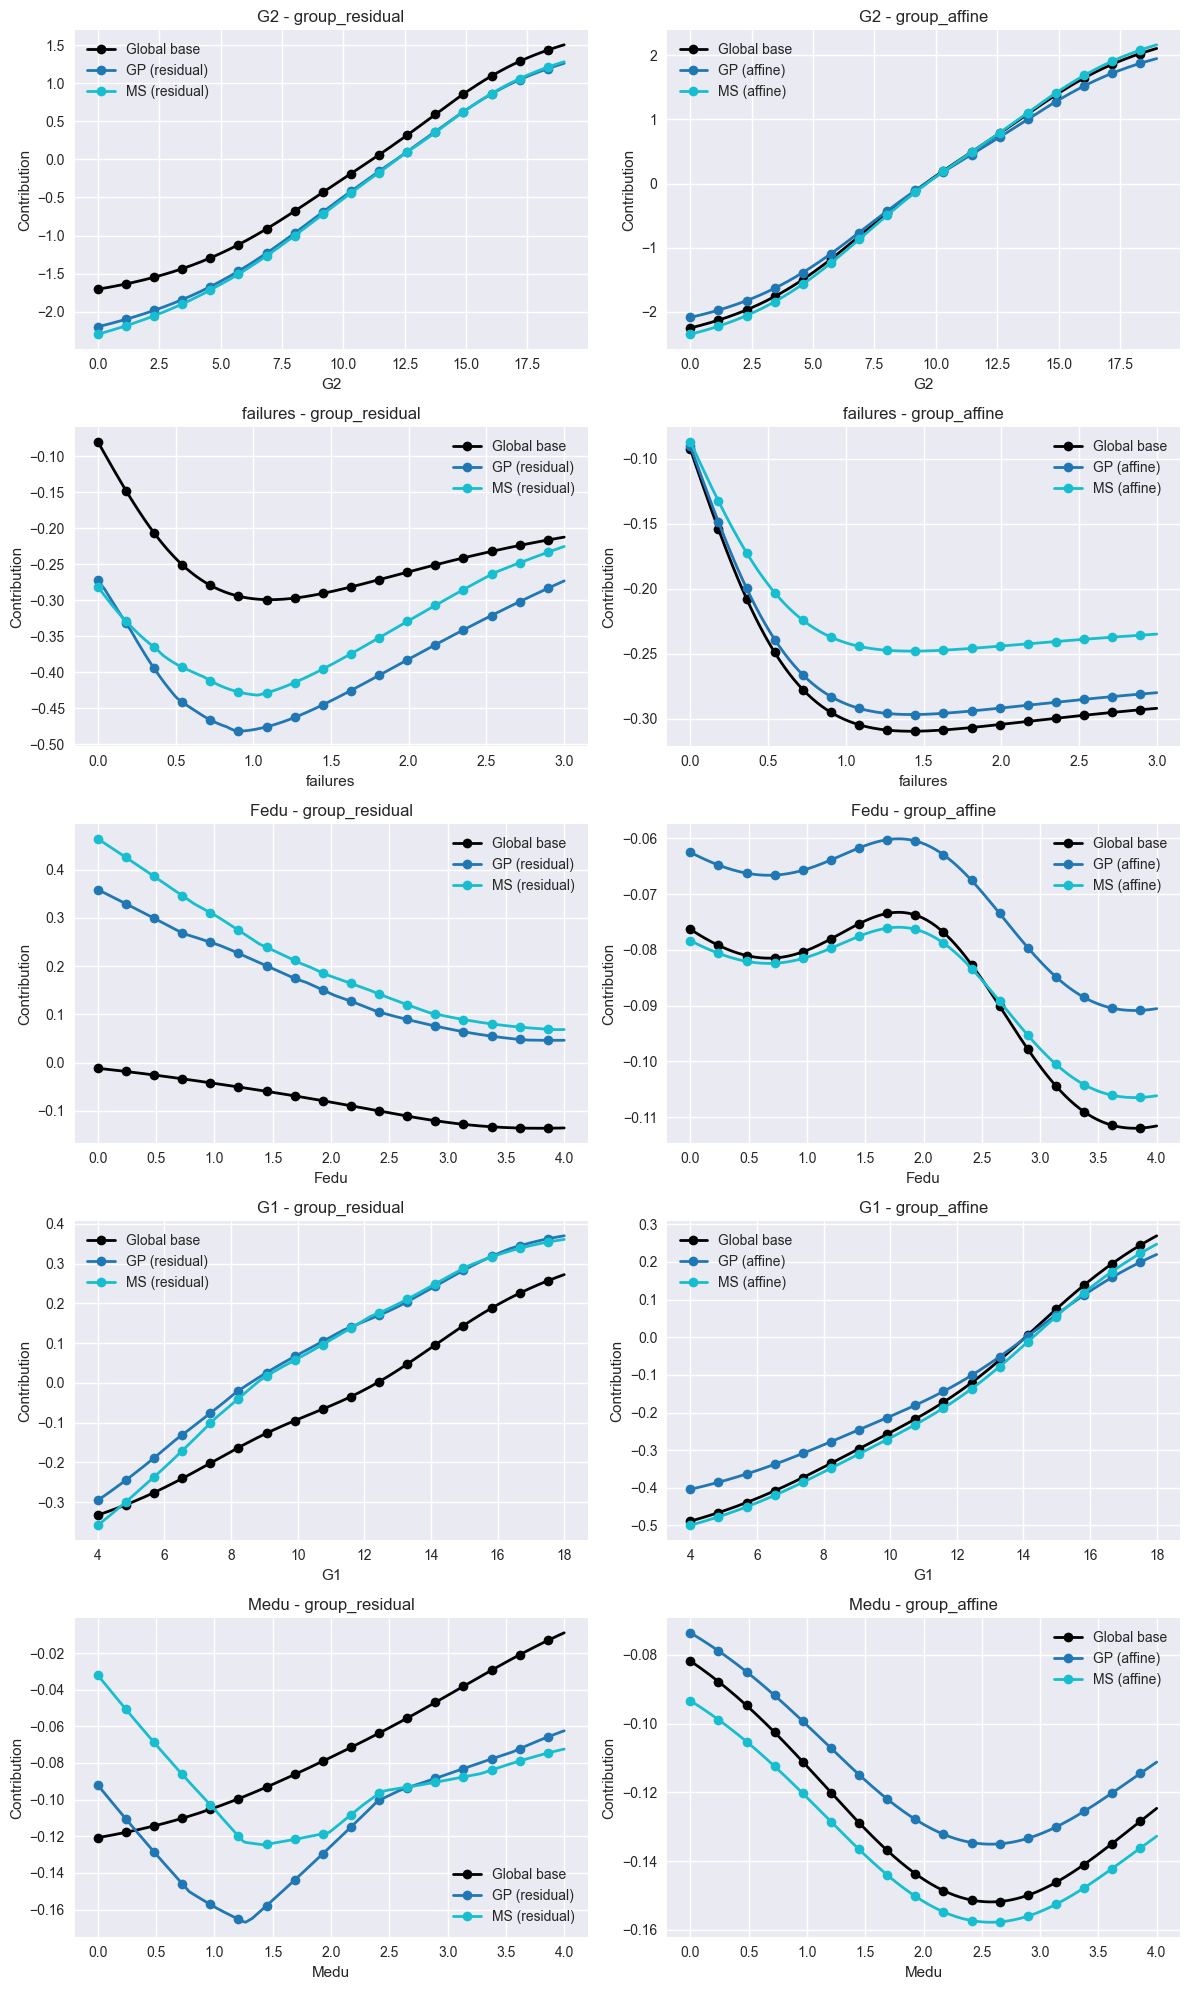

In [26]:
if not trained_models:
    raise RuntimeError('請先完成訓練後再繪圖。')

top_union = []
for mode in modes:
    top_union.extend(feature_scores[mode].head(3).index.tolist())
selected_features = list(dict.fromkeys(top_union))[:7]
if not selected_features:
    selected_features = feature_cols[:7]

fig, axes = plt.subplots(len(selected_features), len(modes), figsize=(12, 4 * len(selected_features)))
axes = np.atleast_2d(axes)

for row, feature in enumerate(selected_features):
    for col, mode in enumerate(modes):
        ax = axes[row, col]
        model = trained_models[mode]
        group_candidates = model.default_groups_[:2]
        if not group_candidates:
            group_candidates = g_train.value_counts().index[:2].tolist()
        model.plot_feature_shapes(
            feature,
            groups=group_candidates,
            mode='group',
            num=200,
            ax=ax,
            markevery=12,
        )
        ax.set_title(f'{feature} - {mode}')

plt.tight_layout()


## 7. Tuning 與 Early Stopping / Checkpoint 流程
- `auto_search=True` + `search_space` 可啟動 Ray Tune（需安裝 `ray[tune]`），也可傳入多組 dict 作為候選組合。
- EarlyStopping / ModelCheckpoint 直接透過 `fit(..., callbacks=[...])` 傳入；第 4 節針對 affine 模式已示範自訂 patience 與輸出位置。
- 若只想保留最後一次 checkpoint，可在自訂 callback 中設定 `save_top_k=0, save_last=True`。
- 實務流程：先用 residual 模式快速掃描 / 觀察 KPI，再改 affine 模式檢查是否需要額外縮放或平移。


In [27]:
def build_search_runner():
    '''建立一個 Ray Tune 搜尋器（需手動呼叫才會執行）。'''
    candidate_space = [
        {'learning_rate': 1e-3, 'base_hidden_units': (64, 32), 'mode': 'group_residual'},
        {'learning_rate': 7e-4, 'base_hidden_units': (96, 48), 'mode': 'group_affine'},
        {'learning_rate': 5e-4, 'base_hidden_units': (128, 64), 'lambda_center': 5e-4},
    ]
    tuner = MixedGAMRegressor(
        auto_search=True,
        # search_space=candidate_space,
        # search_num_samples=len(candidate_space),
        search_metric='val_loss',
        search_mode='min',
        mode='group_residual',
        scaler='standard',
        n_epochs=80,
        batch_size=128,
        random_state=42,
        verbose=True,
    )
    # 解除下一行註解即可啟動 tuning（可能需數分鐘 / 需要 ray[tune]）。
    tuner.fit(X_train, y_train, groups=g_train, val_ratio=0.2)
    return tuner


# tune_runner = None  # 需要時呼叫 build_search_runner() 取得 Ray Tune 物件
tune_runner = build_search_runner()

2025-11-08 23:58:52,678	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\USER\AppData\Local\Temp\ray\session_2025-11-08_23-40-35_734406_13760\artifacts\2025-11-08_23-58-52\_trainable_2025-11-08_23-58-52\driver_artifacts\_trainable_d28c1_00000_0_base_dropout=0.2196,base_hidden_units=64_32,batch_size=256,lambda_group_l1=0.0000,lambda_group_l2=0.0000,_2025-11-08_23-58-52


FileNotFoundError: [WinError 3] 系統找不到指定的路徑。: 'C:\\Users\\USER\\AppData\\Local\\Temp\\ray\\session_2025-11-08_23-40-35_734406_13760\\artifacts\\2025-11-08_23-58-52\\_trainable_2025-11-08_23-58-52\\driver_artifacts\\_trainable_d28c1_00000_0_base_dropout=0.2196,base_hidden_units=64_32,batch_size=256,lambda_group_l1=0.0000,lambda_group_l2=0.0000,_2025-11-08_23-58-52'

## 8. 模型儲存與載入
- MixedGAMRegressor 內建 `save` / `load`，會同時序列化 GAM/adapter 權重與 scaler、encoder。
- 儲存後可直接在推論服務載入並呼叫 `predict` 或 `predict_and_contrib`。


In [14]:
if not trained_models:
    raise RuntimeError('請先訓練至少一個模型再進行保存。')

demo_model = trained_models.get('group_residual') or next(iter(trained_models.values()))
artifacts = Path('artifacts')
artifacts.mkdir(exist_ok=True)
model_ckpt = artifacts / 'mixed_gam.ckpt'
extras_path = artifacts / 'mixed_gam_extras.pkl'

demo_model.save(model_ckpt, extras_path)
reloaded = MixedGAMRegressor.load(model_ckpt, extras_path)
re_preds, _ = reloaded.predict_and_contrib(
    X_test.iloc[:preview_rows],
    groups=g_test.iloc[:preview_rows],
)
ref_preds = prediction_cache[demo_model.mode][:preview_rows]
print(f'Max delta between original and reloaded preds: {np.abs(re_preds - ref_preds).max():.6f}')
print('Reloaded feature importance:')
display(pd.Series(reloaded.feature_importance()).sort_values(ascending=False))

Seed set to 42


Max delta between original and reloaded preds: 0.000000
Reloaded feature importance:


G2           1.834854
failures     0.795373
Fedu         0.659514
studytime    0.572851
Medu         0.488297
G1           0.441321
absences     0.392264
dtype: float64

In [15]:
re_preds[:10]

array([13.35229  ,  8.433799 ,  8.853508 , 10.908706 ,  7.4728794,
       10.857482 ], dtype=float32)

In [16]:
demo_model.predict_and_contrib(
    X_test.iloc[:preview_rows],
    groups=g_test.iloc[:preview_rows],
)[0][:10]

array([13.35229  ,  8.433799 ,  8.853508 , 10.908706 ,  7.4728794,
       10.857482 ], dtype=float32)

(pid=gcs_server) [2025-11-08 23:41:08,444 E 17256 12500] (gcs_server.exe) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2025-11-08 23:41:12,053 E 6244 8108] (raylet.exe) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
